In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração visual padrão para publicações
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 14,
    }
)

DATA_PATH = "../data/processed/boston/boston_master_processed_2001_2026.parquet"

print("⏳ Carregando mega-base processada...")
df = pd.read_parquet(DATA_PATH)

print(f"✅ Base carregada com sucesso!")
print(f"📊 Dimensões: {df.shape[0]:,} maratonistas x {df.shape[1]} colunas")
print(
    f"📅 Período coberto: {df['EventYear'].min()} a {df['EventYear'].max()} ({df['EventYear'].nunique()} edições)"
)

⏳ Carregando mega-base processada...
✅ Base carregada com sucesso!
📊 Dimensões: 563,741 maratonistas x 62 colunas
📅 Período coberto: 2001 a 2026 (25 edições)


--- RELATÓRIO: HIT THE WALL POR GÊNERO (2001-2026) ---
  GenderCode  Total_Atletas  Quebraram  Taxa_Quebra_Pct  Pacing_Ratio_Medio  \
0          F         238018      35622            14.97            1.093405   
1          M         325473      81126            24.93            1.109788   
2          X            250         46            18.40            1.075679   

   Tempo_Medio_Horas  
0               4.06  
1               3.72  
2               3.58  


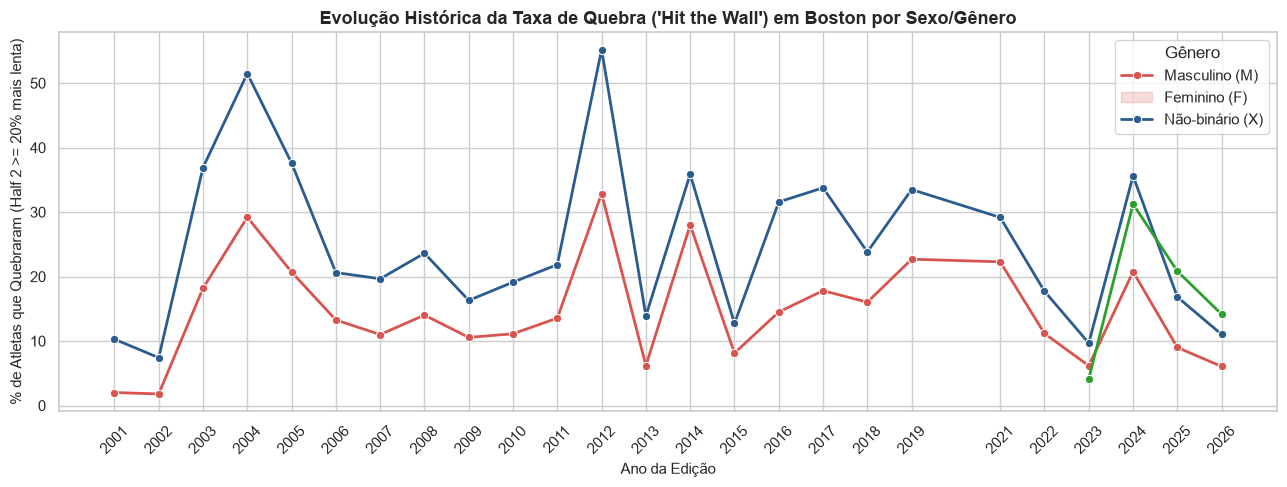

In [5]:
# 1. Tabela de contingência e proporção de 'Hit the Wall' por Sexo/Gênero
wall_by_gender = (
    df.groupby("GenderCode")
    .agg(
        Total_Atletas=("ID", "count"),
        Quebraram=("Hit_The_Wall", "sum"),
        Taxa_Quebra_Pct=("Hit_The_Wall", lambda x: (x.mean() * 100).round(2)),
        Pacing_Ratio_Medio=("Pacing_Ratio", "median"),
        Tempo_Medio_Horas=(
            "ChipFinish_sec",
            lambda s: (s.mean() / 3600).round(2),
        ),
    )
    .reset_index()
)

print("--- RELATÓRIO: HIT THE WALL POR GÊNERO (2001-2026) ---")
print(wall_by_gender)

# 2. Agrupamento anual para visualização
yearly_wall = (
    df.groupby(["EventYear", "GenderCode"])["Hit_The_Wall"]
    .mean()
    .mul(100)
    .reset_index()
)

# 3. Visualização com Seaborn (robusto para M, F e X)
fig, ax = plt.subplots(figsize=(13, 5))

# Paleta com suporte a Masculino (M), Feminino (F) e Não-binário (X)
gender_colors = {"M": "#2b5c8f", "F": "#d9534f", "X": "#2ca02c"}

sns.lineplot(
    data=yearly_wall,
    x="EventYear",
    y="Hit_The_Wall",
    hue="GenderCode",
    palette=gender_colors,
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.set_title(
    "Evolução Histórica da Taxa de Quebra ('Hit the Wall') em Boston por Sexo/Gênero",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("% de Atletas que Quebraram (Half 2 >= 20% mais lenta)")
ax.set_xlabel("Ano da Edição")
ax.set_xticks(sorted(df["EventYear"].unique()))
ax.set_xticklabels(sorted(df["EventYear"].unique()), rotation=45)
ax.legend(title="Gênero", labels=["Masculino (M)", "Feminino (F)", "Não-binário (X)"])

plt.tight_layout()
plt.show()

/var/folders/pq/qqckd4w94h746n_d2btx4yp00000gn/T/ipykernel_11546/3444991792.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/pq/qqckd4w94h746n_d2btx4yp00000gn/T/ipykernel_11546/3444991792.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


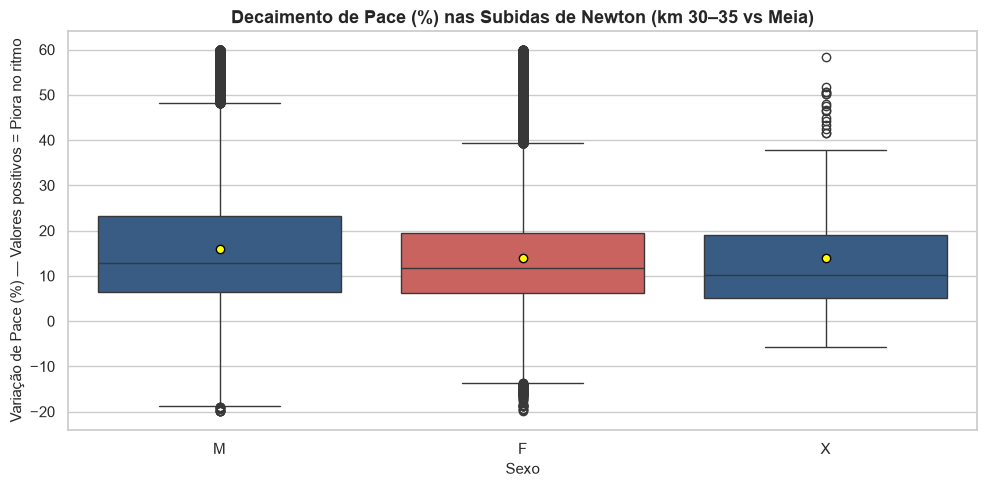

In [3]:
# Decaimento percentual de ritmo no trecho crítico das subidas
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df[df["Newton_Hills_Decay_Pct"].between(-20, 60)],
    x="GenderCode",
    y="Newton_Hills_Decay_Pct",
    palette=["#2b5c8f", "#d9534f"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "yellow",
        "markeredgecolor": "black",
    },
    ax=ax,
)

ax.set_title("Decaimento de Pace (%) nas Subidas de Newton (km 30–35 vs Meia)")
ax.set_ylabel("Variação de Pace (%) — Valores positivos = Piora no ritmo")
ax.set_xlabel("Sexo")
plt.tight_layout()
plt.show()

In [4]:
audit_summary = pd.DataFrame(
    {
        "Métrica": [
            "Total de Concluintes Analisados",
            "Atletas com Tapetes Faltantes (Possível Desvio)",
            "Atletas com Paces Fisiologicamente Impossíveis (< 2:30/km)",
            "Atletas com Negative Split Extremo (Half 2 < 75% da Half 1)",
            "Total Único de Registros com Alguma Flag",
        ],
        "Ocorrências": [
            len(df),
            df["Flag_Missing_Mats"].sum(),
            df["Flag_Pace_Impossivel"].sum(),
            df["Flag_Negative_Split_Extremo"].sum(),
            df[
                [
                    "Flag_Missing_Mats",
                    "Flag_Pace_Impossivel",
                    "Flag_Negative_Split_Extremo",
                ]
            ]
            .any(axis=1)
            .sum(),
        ],
        "% da Base": [
            100.0,
            (df["Flag_Missing_Mats"].mean() * 100).round(3),
            (df["Flag_Pace_Impossivel"].mean() * 100).round(3),
            (df["Flag_Negative_Split_Extremo"].mean() * 100).round(3),
            (
                df[
                    [
                        "Flag_Missing_Mats",
                        "Flag_Pace_Impossivel",
                        "Flag_Negative_Split_Extremo",
                    ]
                ]
                .any(axis=1)
                .mean()
                * 100
            ).round(3),
        ],
    }
)

print("--- SUMÁRIO DE AUDITORIA ÉTICA (2001-2026) ---")
print(audit_summary.to_string(index=False))

--- SUMÁRIO DE AUDITORIA ÉTICA (2001-2026) ---
                                                    Métrica  Ocorrências  % da Base
                            Total de Concluintes Analisados       563741    100.000
            Atletas com Tapetes Faltantes (Possível Desvio)        14961      2.654
 Atletas com Paces Fisiologicamente Impossíveis (< 2:30/km)           33      0.006
Atletas com Negative Split Extremo (Half 2 < 75% da Half 1)          145      0.026
                   Total Único de Registros com Alguma Flag        15128      2.684
